# 오류 대응 탐지 성능 평가 (item15)

**파이프라인**: `item15_error_handling.run()` — 실습 청크에 정규식 패턴 매칭 → 오류 후보 탐지  
**정답지**: `data/goldset/*_error_goldset_final.json`  
**매칭**: word containment (골드셋 텍스트가 탐지 청크에 포함되는 비율)  
**핵심 지표**: 파일별 Precision / Recall

In [2]:
import sys
sys.path.insert(0, "..")

import json
import glob
from pathlib import Path

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["axes.unicode_minus"] = False
for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break

from app.preprocessing.item15_error_handling import run as error_run

GOLDSET_DIR  = Path("../data/goldset")
ANCHORED_PATH = Path("../data/anchored_labeled.json")
EVAL_DATES   = ["2026-02-09", "2026-02-10", "2026-02-11", "2026-02-12", "2026-02-13"]
MATCH_THRESHOLD = 0.3

with open(ANCHORED_PATH) as f:
    anchored_all = json.load(f)

print("anchored 전체:", len(anchored_all))

anchored 전체: 1279


In [3]:
def word_containment(gold_text: str, pred_text: str) -> float:
    """gold 단어 중 pred에 포함된 비율 (gold ⊆ pred 방향)"""
    g = set(gold_text.split())
    p = set(pred_text.split())
    return len(g & p) / len(g) if g else 0.0


def load_error_goldset(date: str) -> list[dict]:
    path = GOLDSET_DIR / f"{date}_error_goldset_final.json"
    if not path.exists():
        return []
    with open(path) as f:
        data = json.load(f)
    return data.get("errors", [])


def evaluate_date(date: str) -> dict:
    """
    한 날짜에 대해 오류 탐지 precision/recall 계산.

    - 골드셋 오류 스팬을 각각 실습 청크에 매칭
    - 파이프라인이 해당 청크를 candidate로 잡았는지 확인
    """
    gold_errors = load_error_goldset(date)
    day_chunks  = [d for d in anchored_all if date in d["file"]]

    if not day_chunks:
        return {"date": date, "gold_count": len(gold_errors), "skipped": True}

    df = pd.DataFrame(day_chunks)
    result = error_run(df)
    candidates = result["candidates"]   # 파이프라인이 탐지한 오류 후보
    practice   = result["practice"]     # 실습 청크 전체

    candidate_texts = {c["text"] for c in candidates}

    # ── 골드셋 기준: 각 gold error → best matching 실습 청크 찾기 ──
    gold_records = []
    for err in gold_errors:
        if not practice:
            gold_records.append({"gold_name": err["error_name"], "pred": 0, "gold": 1, "score": 0.0})
            continue
        scores = [(word_containment(err["text"], p["text"]), p["text"]) for p in practice]
        best_score, best_text = max(scores, key=lambda x: x[0])
        matched = best_score >= MATCH_THRESHOLD
        detected = matched and (best_text in candidate_texts)
        gold_records.append({
            "gold_name": err["error_name"],
            "gold": 1,
            "pred": int(detected),
            "score": best_score,
        })

    # ── 파이프라인 기준: FP 집계 (candidate 중 gold에 없는 것) ──
    for c in candidates:
        if not gold_errors:
            gold_records.append({"gold_name": "(FP)", "gold": 0, "pred": 1, "score": 0.0})
            continue
        scores = [word_containment(e["text"], c["text"]) for e in gold_errors]
        best = max(scores)
        if best < MATCH_THRESHOLD:
            gold_records.append({"gold_name": "(FP)", "gold": 0, "pred": 1, "score": best})

    # ── gold=0, detected=0 인 경우 빈 레코드 방어 ──
    if not gold_records:
        empty_detail = pd.DataFrame(columns=["gold_name", "gold", "pred", "score"])
        return {
            "date": date,
            "gold_count":      0,
            "detected_count":  0,
            "TP": 0, "FN": 0, "FP": 0,
            "precision": 0.0,
            "recall":    0.0,
            "f1":        0.0,
            "detail":    empty_detail,
        }

    gdf = pd.DataFrame(gold_records)
    y_true = gdf["gold"].tolist()
    y_pred = gdf["pred"].tolist()

    return {
        "date": date,
        "gold_count":      len(gold_errors),
        "detected_count":  len(candidates),
        "TP": sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1),
        "FN": sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0),
        "FP": sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "detail":    gdf,
    }

results = {}
for date in EVAL_DATES:
    results[date] = evaluate_date(date)
    r = results[date]
    if r.get("skipped"):
        print(f"{date}: anchored 데이터 없음")
    else:
        print(f"{date}: gold={r['gold_count']} detected={r['detected_count']} "
              f"TP={r['TP']} FN={r['FN']} FP={r['FP']} "
              f"P={r['precision']:.2f} R={r['recall']:.2f} F1={r['f1']:.2f}")

2026-02-09: gold=5 detected=7 TP=4 FN=1 FP=0 P=1.00 R=0.80 F1=0.89
2026-02-10: gold=1 detected=0 TP=0 FN=1 FP=0 P=0.00 R=0.00 F1=0.00
2026-02-11: gold=8 detected=13 TP=6 FN=2 FP=1 P=0.86 R=0.75 F1=0.80
2026-02-12: gold=0 detected=0 TP=0 FN=0 FP=0 P=0.00 R=0.00 F1=0.00
2026-02-13: gold=11 detected=12 TP=11 FN=0 FP=0 P=1.00 R=1.00 F1=1.00


In [4]:
# 파일별 요약 테이블
summary_rows = []
for date, r in results.items():
    if r.get("skipped"):
        continue
    summary_rows.append({
        "date":      date,
        "gold": r["gold_count"],
        "detected":  r["detected_count"],
        "TP":        r["TP"],
        "FN":        r["FN"],
        "FP":        r["FP"],
        "precision": round(r["precision"], 3),
        "recall":    round(r["recall"],    3),
        "f1":        round(r["f1"],        3),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,date,gold,detected,TP,FN,FP,precision,recall,f1
0,2026-02-09,5,7,4,1,0,1.000,0.80,0.889
1,2026-02-10,1,0,0,1,0,0.000,0.00,0.000
2,2026-02-11,8,13,6,2,1,0.857,0.75,0.800
3,2026-02-12,0,0,0,0,0,0.000,0.00,0.000
4,2026-02-13,11,12,11,0,0,1.000,1.00,1.000


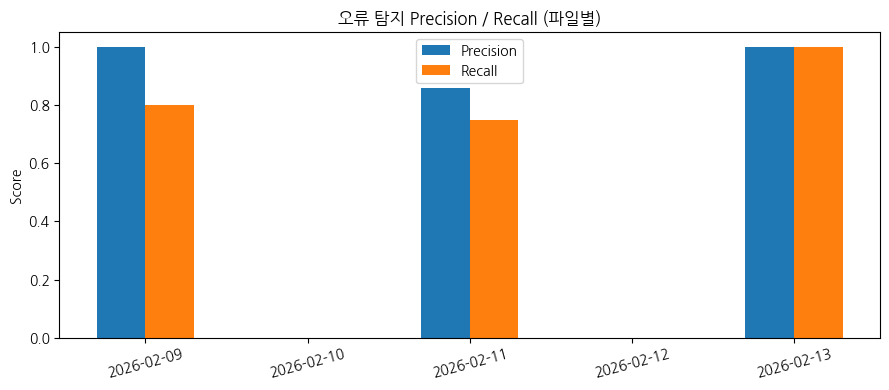

In [5]:
# 파일별 Precision / Recall 바 차트
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(summary_df))
w = 0.3
ax.bar([i - w/2 for i in x], summary_df["precision"], w, label="Precision")
ax.bar([i + w/2 for i in x], summary_df["recall"],    w, label="Recall")
ax.set_xticks(list(x))
ax.set_xticklabels(summary_df["date"], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("오류 탐지 Precision / Recall (파일별)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# 오분류 상세 (FN: 놓친 오류, FP: 과탐지)
for date, r in results.items():
    if r.get("skipped"):
        continue
    detail = r["detail"]
    fn_rows = detail[(detail["gold"] == 1) & (detail["pred"] == 0)]
    fp_rows = detail[(detail["gold"] == 0) & (detail["pred"] == 1)]
    if len(fn_rows) == 0 and len(fp_rows) == 0:
        continue
    print(f"\n{'='*60}")
    print(f"{date}")
    if len(fn_rows):
        print(f"  FN (놓친 오류 {len(fn_rows)}건):")
        for _, row in fn_rows.iterrows():
            print(f"    - {row['gold_name']} (매칭점수 {row['score']:.2f})")
    if len(fp_rows):
        print(f"  FP (과탐지 {len(fp_rows)}건)")


2026-02-09
  FN (놓친 오류 1건):
    - 미설치 Collation 사용 시 오류 발생 (매칭점수 0.37)

2026-02-10
  FN (놓친 오류 1건):
    - 셀프 조인 결과 누락 (매칭점수 0.38)

2026-02-11
  FN (놓친 오류 2건):
    - 쿼리 논리 오류 수정 및 설명 (매칭점수 1.00)
    - 쿼리 작성 중 함수 오기입 수정 (매칭점수 1.00)
  FP (과탐지 1건)
